# 2D clinic Hamiltonian — elastic $H$ structure

Study the **3D elastic evolution Hamiltonian** from the clinic code, focusing on matrix structure before block encoding.

**Operator** (`_utility.FD_solver_3D_elastic`):
$$
H = i\,B^{-1/2} A\,B^{-1/2}, \qquad \dot\psi = -i H \psi.
$$

**Note:** there is no separate 2D elastic builder in `_utility.py`. This notebook uses **3D elastic** on a small grid with **thin $N_z$** (a quasi-2D $xy$ slice with minimal $z$ extent). That is the same staggered $(v,\sigma)$ formulation as the full clinic.

**State ordering** (`plot_elastic_3D`):
$$
\psi = [\,v_x \mid v_y \mid v_z \mid \sigma_{xx} \mid \sigma_{yy} \mid \sigma_{zz} \mid \sigma_{xy} \mid \sigma_{xz} \mid \sigma_{yz}\,].
$$

**Sections**
1. Build / verify $H$
2. Velocity–stress block structure
3. Pechan coefficient labeling
4. Verify labeling recovers $H$
5. $O_{\mathrm{data}}$ scaling
6. Split $B^{-1/2}$ vs $iA$ oracles
7. Staggered index oracles ($2\times 2\times 2$)
8. Assembled $U_H$ circuit (small grid)
9. Gate / depth table vs $N_s$
10. Small-grid $U_H$ content vs classical $H$
11. Time evolution (replace \texttt{MatrixExponential})

**Related notebooks**
- Scalar Poisson oracle (different matrix $G$): [`block_encoding_laplacian_2d_two_material.ipynb`](block_encoding_laplacian_2d_two_material.ipynb)
- 1D LCU basics: [`block_encoding_laplacian_1d.ipynb`](block_encoding_laplacian_1d.ipynb)

Helper modules: `_utility.py`, `_block_encoding_hamiltonian.py`.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(os.getcwd()))
import importlib
import _block_encoding_hamiltonian as be_h
importlib.reload(be_h)
from _block_encoding_hamiltonian import (
    anti_hermitian_error,
    block_boundaries,
    build_hamiltonian_block_encoding_circuit,
    build_hamiltonian_oracle_labeling,
    build_minimal_hamiltonian_demo,
    clinic_elastic_materials,
    coefficient_labeling_table,
    compare_evolution_to_direct,
    compare_uh_to_classical,
    dense_matrix,
    diagonal_material_catalog,
    elastic_3d_layout,
    evolve_with_assembled_uh,
    hamiltonian_gate_budget_report,
    hermitian_error,
    imag_payload,
    label_coefficients_by_block,
    label_material_and_coupling,
    odata_budget_for_labeling,
    summarize_block_coupling,
    summarize_coefficient_labeling,
    summarize_hamiltonian_odata_scaling,
    summarize_uh_gate_scaling,
    verify_labeling,
    verify_staggered_index_oracles,
)
from _block_encoding_common import spectral_scale, transpiled_gate_counts, data_loading_subcircuit
from _utility import FD_solver_3D_elastic


## 1. Build clinic elastic $H$ and verify structure

Small 3D elastic grid ($N_x=N_y=4$, $N_z=2$) with clinic rock/fracture materials. We assemble $H$, $A$, $B$ via `FD_solver_3D_elastic`, check $A^\top \approx -A$ and $H^\dagger \approx H$, and plot the sparsity pattern with velocity/stress block boundaries.

In [2]:
NX, NY, NZ = 4, 4, 2
DX = DY = DZ = 0.05
BCS = {"L": "DBC", "R": "DBC", "T": "DBC", "B": "DBC", "F": "DBC", "Ba": "DBC"}

rho_model, S, fracture_mask = clinic_elastic_materials(NX, NY, NZ, add_fractures=True)
layout = elastic_3d_layout(NX, NY, NZ)

print("DOF layout [v | sigma]:")
for name, sl in layout.slices().items():
    print(f"  {name:10s}  indices {sl.start:4d}:{sl.stop:4d}  (size {sl.stop - sl.start})")
print(f"\nVelocity DOFs: {layout.n_vel}   Stress DOFs: {layout.n_stress}   Total N = {layout.n_total}")
print(f"Fracture cells: {fracture_mask.sum()} / {fracture_mask.size}")

H, A, B, B_sqrt, B_inv, B_inv_sqrt = FD_solver_3D_elastic(
    NX, NY, NZ, DX, DY, DZ, rho_model, S, BCS
)

print(f"\n|A + A^T|_max = {anti_hermitian_error(A):.2e}")
print(f"|H - H^dagger|_max = {hermitian_error(H):.2e}")
print(f"||H||_2 = {np.linalg.norm(dense_matrix(H), 2):.4g}")

DOF layout [v | sigma]:
  v_x         indices    0:  24  (size 24)
  v_y         indices   24:  48  (size 24)
  v_z         indices   48:  64  (size 16)
  sigma_xx    indices   64:  96  (size 32)
  sigma_yy    indices   96: 128  (size 32)
  sigma_zz    indices  128: 160  (size 32)
  sigma_xy    indices  160: 178  (size 18)
  sigma_xz    indices  178: 190  (size 12)
  sigma_yz    indices  190: 202  (size 12)

Velocity DOFs: 64   Stress DOFs: 138   Total N = 202
Fracture cells: 20 / 32

|A + A^T|_max = 0.00e+00
|H - H^dagger|_max = 2.91e-11
||H||_2 = 2.485e+05


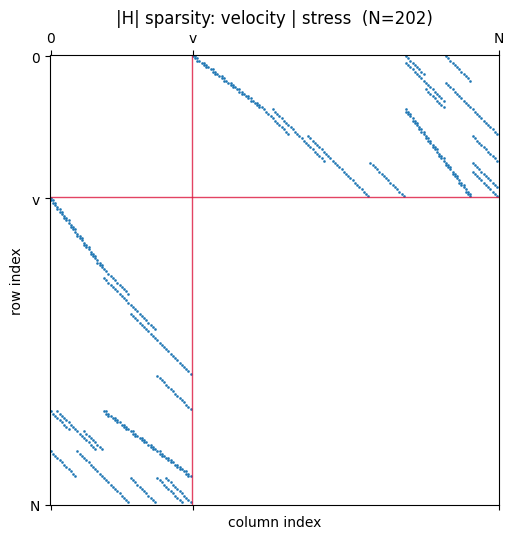

In [3]:
H_dense = dense_matrix(H)
ticks = block_boundaries(layout, coarse=True)
tick_labels = ["0", "v", "N"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.spy(np.abs(H_dense) > 0, markersize=0.8, color="C0")
for t in ticks[1:-1]:
    ax.axhline(t - 0.5, color="crimson", lw=1.0, alpha=0.8)
    ax.axvline(t - 0.5, color="crimson", lw=1.0, alpha=0.8)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)
ax.set_xlabel("column index")
ax.set_ylabel("row index")
ax.set_title(f"|H| sparsity: velocity | stress  (N={layout.n_total})")
plt.tight_layout()
plt.show()

## 2. Block annotation: velocity–stress structure of $H$

The first-order elastic system matrix has the block layout (`compute_A_elastic_3D`)
$$
A = \begin{pmatrix} 0 & D \\ -D^\top & 0 \end{pmatrix},
$$
on $[v_x, v_y, v_z \mid \sigma_{xx}, \ldots, \sigma_{yz}]$, with $D$ the staggered divergence linking stress to velocity.

$B^{-1/2}$ is **block-diagonal** in the same ordering: density on velocity blocks, compliance on stress blocks. Fractures change local $B$ entries (and hence $H$) without changing the global block template.

Below: coarse velocity$\leftrightarrow$stress coupling, fine block table for $A$, and a zoom on one $D$ tile ($v_x \leftarrow \sigma_{xx}$).

In [4]:
def coupling_table(matrix, block_slices, label):
    rows = []
    for (row_name, col_name), (nnz, peak) in summarize_block_coupling(
        dense_matrix(matrix), block_slices
    ).items():
        rows.append({
            "matrix": label,
            "row_block": row_name,
            "col_block": col_name,
            "nnz": nnz,
            "max_abs": peak,
        })
    return pd.DataFrame(rows)

coarse = layout.coarse_slices()
df_coarse = coupling_table(H, coarse, "H")
display(df_coarse.pivot_table(
    index="row_block", columns="col_block", values="nnz", fill_value=0
))

df_fine = coupling_table(A, layout.slices(), "A")
pivot = df_fine.pivot_table(
    index="row_block", columns="col_block", values="nnz", fill_value=0
)
print("Nonzero counts in A (fine blocks):")
display(pivot.loc[["v_x", "v_y", "v_z"], [c for c in pivot.columns if c.startswith("sigma")]])

col_block,stress,velocity
row_block,,
stress,0.0,296.0
velocity,296.0,0.0


Nonzero counts in A (fine blocks):


col_block,sigma_xx,sigma_xy,sigma_xz,sigma_yy,sigma_yz,sigma_zz
row_block,,,,,,
v_x,48.0,36.0,24.0,0.0,0.0,0.0
v_y,0.0,36.0,0.0,48.0,24.0,0.0
v_z,0.0,0.0,24.0,0.0,24.0,32.0


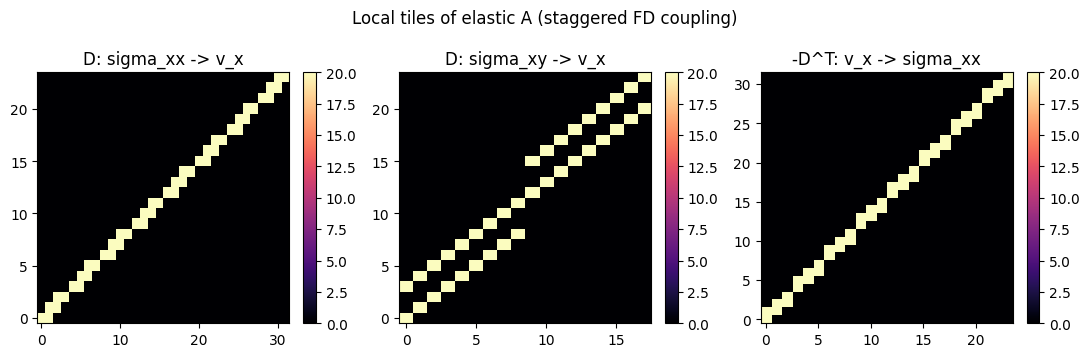

Takeaway: H is block-sparse with velocity-stress coupling; not a scalar 5-point Laplacian.


In [5]:
A_dense = dense_matrix(A)
vx_sl, sxx_sl = layout.vx_slice, layout.sxx_slice

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
panels = [
    ("D: sigma_xx -> v_x", A_dense[vx_sl, sxx_sl]),
    ("D: sigma_xy -> v_x", A_dense[vx_sl, layout.sxy_slice]),
    ("-D^T: v_x -> sigma_xx", A_dense[sxx_sl, vx_sl]),
]
for ax, (title, block) in zip(axes, panels):
    im = ax.imshow(np.abs(block), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Local tiles of elastic A (staggered FD coupling)")
plt.tight_layout()
plt.show()

print("Takeaway: H is block-sparse with velocity-stress coupling; not a scalar 5-point Laplacian.")

In [6]:
# Homogeneous vs fractured H: which block tiles change?
rho_homo, S_homo, _ = clinic_elastic_materials(NX, NY, NZ, add_fractures=False)
H_homo, *_ = FD_solver_3D_elastic(NX, NY, NZ, DX, DY, DZ, rho_homo, S_homo, BCS)

base = summarize_block_coupling(dense_matrix(H_homo), coarse)
frac = summarize_block_coupling(dense_matrix(H), coarse)
changed = [
    key for key in base
    if base[key][0] != frac[key][0]
    or not np.isclose(base[key][1], frac[key][1])
]
print(f"Coarse tiles changed by fractures: {changed}")


Coarse tiles changed by fractures: [('velocity', 'stress'), ('stress', 'velocity')]


## 3. Label distinct coefficients per block (oracle design)

Pechan-style relabeling for $H$: each nonzero entry belongs to a **block section**
$(\text{row\_block}, \text{col\_block})$.  Distinct values within a section get
$d_{\mathrm{val}}$; the section index is $d_{\mathrm{ind}}$, so
$$
d = d_{\mathrm{ind}}\,\|\, d_{\mathrm{val}}.
$$
The same magnitude in different sections receives **different** $d$ labels (needed for $O_{\mathrm{data}}$).

We also catalog diagonal **material** coefficients in $B^{-1/2}$ per block — the natural split before encoding $iA$ and $B^{-1/2}$ separately.

In [7]:
labeling_H = label_coefficients_by_block(H, layout, matrix_name="H")
summary_H = summarize_coefficient_labeling(labeling_H)

print(f"H: D' = {summary_H['D_prime']} distinct labels  (D_padded = {summary_H['D_padded']})")
print(f"    sections = {summary_H['n_sections']},  d_ind bits = {summary_H['d_ind_bits']},  d_val bits = {summary_H['d_val_bits']}")
print(f"    n_d qubits ~ {summary_H['n_d_qubits']}")

display(coefficient_labeling_table(labeling_H))

H: D' = 96 distinct labels  (D_padded = 256)
    sections = 18,  d_ind bits = 5,  d_val bits = 3
    n_d qubits ~ 8


,section,n_distinct,matrix
0,sigma_xx -> v_x,8,H
1,sigma_xy -> v_x,6,H
2,sigma_xy -> v_y,8,H
3,sigma_xz -> v_x,4,H
4,sigma_xz -> v_z,6,H
5,sigma_yy -> v_y,4,H
6,sigma_yz -> v_y,4,H
7,sigma_yz -> v_z,4,H
8,sigma_zz -> v_z,4,H
9,v_x -> sigma_xx,8,H


In [8]:
# Coupling sections (velocity <-> stress) carry fracture-induced coefficient variety
coupling_sections = [
    row for row in summary_H["distinct_values_per_section"]
    if ("v_" in row.split(" -> ")[0] and "sigma" in row.split(" -> ")[1])
    or ("sigma" in row.split(" -> ")[0] and "v_" in row.split(" -> ")[1])
]
rows = []
for section in coupling_sections:
    vals = summary_H["section_values"][section]
    rows.append({
        "section": section,
        "n_distinct": len(vals),
        "sample": [f"{v.real:.4g}" for v in vals[:4]],
    })
display(pd.DataFrame(rows))

material_df = diagonal_material_catalog(B_inv_sqrt, layout)
print("\nDiagonal B^{-1/2} material catalog (per block):")
display(material_df[["block", "n_dof", "n_distinct"]])

,section,n_distinct,sample
0,sigma_xx -> v_x,8,"[0, 0, 0, 0]"
1,sigma_xy -> v_x,6,"[0, 0, 0, 0]"
2,sigma_xy -> v_y,8,"[0, 0, 0, 0]"
3,sigma_xz -> v_x,4,"[0, 0, 0, 0]"
4,sigma_xz -> v_z,6,"[0, 0, 0, 0]"
5,sigma_yy -> v_y,4,"[0, 0, 0, 0]"
6,sigma_yz -> v_y,4,"[0, 0, 0, 0]"
7,sigma_yz -> v_z,4,"[0, 0, 0, 0]"
8,sigma_zz -> v_z,4,"[0, 0, 0, 0]"
9,v_x -> sigma_xx,8,"[0, 0, 0, 0]"



Diagonal B^{-1/2} material catalog (per block):


,block,n_dof,n_distinct
0,v_x,24,3
1,v_y,24,2
2,v_z,16,2
3,sigma_xx,32,2
4,sigma_yy,32,2
5,sigma_zz,32,2
6,sigma_xy,18,3
7,sigma_xz,12,2
8,sigma_yz,12,2


In [9]:
# Homogeneous vs fractured: how label count scales
labeling_homo = label_coefficients_by_block(H_homo, layout, matrix_name="H_homo")

rows = []
for name, labeling in [("fractured", labeling_H), ("homogeneous", labeling_homo)]:
    s = summarize_coefficient_labeling(labeling)
    rows.append({
        "case": name,
        "D_prime": s["D_prime"],
        "n_sections": s["n_sections"],
        "max_distinct_in_section": max(s["distinct_values_per_section"].values()),
    })
display(pd.DataFrame(rows))

,case,D_prime,n_sections,max_distinct_in_section
0,fractured,96,18,8
1,homogeneous,36,18,2


## 4. Verify labeling recovers $H$

Rebuild $H$ from Pechan labels / value table and check entrywise agreement (same role as Section 4 in the Laplacian notebook).

In [10]:
check = verify_labeling(labeling_H, H)
print("Labeling verification:", check)
assert check["max_abs_error"] < 1e-10
assert check["nnz_mask_mismatches"] == 0

# Purely imaginary Hermitian: Re(H)=0 so O_data loads Im(H)
H_dense_check = dense_matrix(H)
print(f"max|Re(H)| = {np.max(np.abs(H_dense_check.real)):.2e}")
print(f"max|Im(H)| = {np.max(np.abs(H_dense_check.imag)):.4g}")


Labeling verification: {'max_abs_error': 3.4022144910356156e-13, 'nnz_mask_mismatches': 0.0, 'value_table_error': 0.0}
max|Re(H)| = 0.00e+00
max|Im(H)| = 1.333e+05


## 5. $O_{\mathrm{data}}$ scaling with grid size

Fast sweep of $D'$ and transpiled $O_{\mathrm{data}}$ depth/size on `Im(H)` (clinic $H$ is purely imaginary). Uses `summarize_hamiltonian_odata_scaling` — no index-oracle assembly. Set `sk_t_count=True` only if you need Solovay–Kitaev T-gates.

,nx,ny,nz,N,D_prime,D_padded,n_sections,n_d_qubits,O_data_depth,O_data_size,O_data_t_gates,alpha_Im
0,2,2,2,42,64,128,18,7,19068,20843,4826,156029.686784
1,4,2,2,92,96,256,18,8,42843,57598,21440,219391.613924
2,4,4,2,202,96,256,18,8,42843,57598,21440,248511.586832


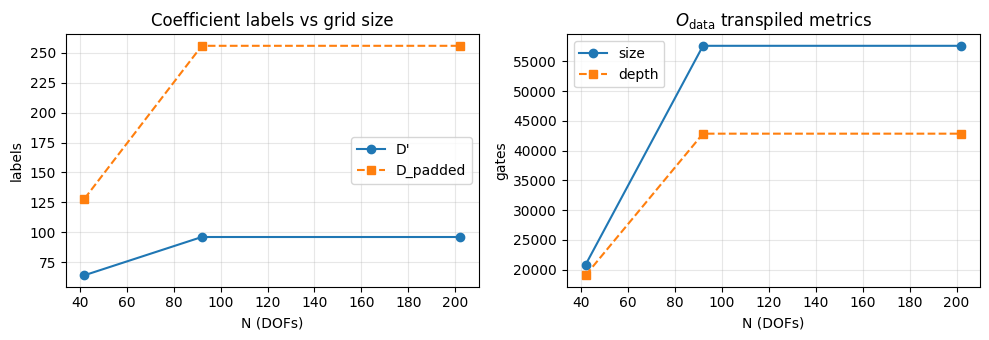

In [11]:
odata_scale = summarize_hamiltonian_odata_scaling(
    ((2, 2, 2), (4, 2, 2), (4, 4, 2)),
    add_fractures=True,
    sk_t_count=False,
)
display(odata_scale)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(odata_scale["N"], odata_scale["D_prime"], "o-", label="D'")
ax[0].plot(odata_scale["N"], odata_scale["D_padded"], "s--", label="D_padded")
ax[0].set_xlabel("N (DOFs)")
ax[0].set_ylabel("labels")
ax[0].set_title("Coefficient labels vs grid size")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(odata_scale["N"], odata_scale["O_data_size"], "o-", label="size")
ax[1].plot(odata_scale["N"], odata_scale["O_data_depth"], "s--", label="depth")
ax[1].set_xlabel("N (DOFs)")
ax[1].set_ylabel("gates")
ax[1].set_title(r"$O_{\mathrm{data}}$ transpiled metrics")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Split $B^{-1/2}$ vs $iA$ oracles (physics-faithful encoding)

Clinic evolution uses
$$
H = i\,B^{-1/2} A\,B^{-1/2}.
$$
Label and budget **material** ($B^{-1/2}$, diagonal) and **coupling** ($iA$) separately, then verify the product reconstitutes $H$.

In [12]:
factors = label_material_and_coupling(A, B_inv_sqrt, layout)
print("iA:", {k: factors["summary_iA"][k] for k in ("D_prime", "D_padded", "n_sections", "n_d_qubits")})
print("B_inv_sqrt:", {k: factors["summary_B_inv_sqrt"][k] for k in ("D_prime", "D_padded", "n_sections", "n_d_qubits")})
print("verify iA:", factors["verify_iA"])
print("verify B_inv_sqrt:", factors["verify_B_inv_sqrt"])

product_err = np.max(np.abs(dense_matrix(H) - factors["H_from_factors"]))
print(f"|H - i B^{{-1/2}} A B^{{-1/2}}|_max = {product_err:.2e}")
assert product_err < 1e-10

budgets = pd.DataFrame(
    [
        {"operator": "H", **{k: odata_budget_for_labeling(labeling_H, sk_t_count=False)[k] for k in ("alpha", "depth", "size", "t_gates")}},
        {"operator": "iA", **{k: odata_budget_for_labeling(factors["labeling_iA"], sk_t_count=False)[k] for k in ("alpha", "depth", "size", "t_gates")}},
        {
            "operator": "B_inv_sqrt",
            **{
                k: odata_budget_for_labeling(factors["labeling_B_inv_sqrt"], use_imag=False, sk_t_count=False)[k]
                for k in ("alpha", "depth", "size", "t_gates")
            },
        },
    ]
)
display(budgets)
display(factors["material_catalog"][["block", "n_dof", "n_distinct"]])


iA: {'D_prime': 36, 'D_padded': 64, 'n_sections': 18, 'n_d_qubits': 6}
B_inv_sqrt: {'D_prime': 20, 'D_padded': 64, 'n_sections': 9, 'n_d_qubits': 6}
verify iA: {'max_abs_error': 0.0, 'nnz_mask_mismatches': 0.0, 'value_table_error': 0.0}
verify B_inv_sqrt: {'max_abs_error': 3.7925153469065e-13, 'nnz_mask_mismatches': 0.0, 'value_table_error': 0.0}
|H - i B^{-1/2} A B^{-1/2}|_max = 0.00e+00


,operator,alpha,depth,size,t_gates
0,H,248511.586832,42843,57598,21440
1,iA,76.436357,4043,7128,0
2,B_inv_sqrt,286644.838010,4043,7128,0


,block,n_dof,n_distinct
0,v_x,24,3
1,v_y,24,2
2,v_z,16,2
3,sigma_xx,32,2
4,sigma_yy,32,2
5,sigma_zz,32,2
6,sigma_xy,18,3
7,sigma_xz,12,2
8,sigma_yz,12,2


## 7. Staggered index oracles on a minimal grid

On $2\times 2\times 2$ (homogeneous, $N=42$), build Pechan-style $(d,m)\to(i,j)$ maps and lookup $O_c$, $O_r$ for the staggered elastic layout. Index register is padded to a power of two (clinic DOF counts are not powers of two).

In [13]:
demo = build_minimal_hamiltonian_demo(2, 2, 2, add_fractures=False)
oracle = demo["oracle"]
oracle_check = demo["oracle_check"]

print("Minimal-grid layout: N =", demo["layout"].n_total)
print("Oracle registers: n_d =", oracle.n_d_qubits, ", n_m =", oracle.n_m_qubits, ", n_idx =", oracle.n_index_qubits)
print("Full U_H qubit count (data|d|m|idx):", oracle.num_qubits_uh)
print("Oracle check:", oracle_check)
assert oracle_check["ok"]

print("verify H on minimal grid:", demo["verify_H"])
assert demo["verify_H"]["max_abs_error"] < 1e-10


Minimal-grid layout: N = 42
Oracle registers: n_d = 6 , n_m = 2 , n_idx = 6
Full U_H qubit count (data|d|m|idx): 15
Oracle check: {'n_entries': 96, 'duplicates': 0, 'missing_nnz': 0, 'extra_coverage': 0, 'oracle_chain_errors': 0, 'n_d_qubits': 6, 'n_m_qubits': 2, 'n_index_qubits': 6, 'num_qubits_uh': 15, 'ok': True}
verify H on minimal grid: {'max_abs_error': 0.0, 'nnz_mask_mismatches': 0.0, 'value_table_error': 0.0}


## 8. Assembled block-encoding circuit $U_H$ (small grid)

Same Pechan / Sünderhauf assembly as the Laplacian notebook (`O_c^{-1} \cdot O_{\mathrm{data}} \cdot Z \cdot O_t \cdot O_r` on `data | d | m | idx`), but for clinic elastic $\mathrm{Im}(H)$.

**Note:** staggered elastic grids need a **padded index register** ($N=42 \to 64$), so lookup oracles are shown as **opaque gates** (`O_c`, `O_c_inv`, `O_r`, `O_t`) — dense `UnitaryGate` synthesis would require a $2^{14}$ matrix on $2\times2\times2$. Set `materialize_lookup=True` only on toy sizes.

In [14]:
circuit_uh, alpha_uh = build_hamiltonian_block_encoding_circuit(oracle)
print(f"U_H: {circuit_uh.num_qubits} qubits, depth {circuit_uh.depth()}, size {circuit_uh.size()}")
print(f"alpha = ||Im(H)||_2 = {alpha_uh:.4g}\n")
print(circuit_uh.draw(output="text", fold=-1))

budget_uh = hamiltonian_gate_budget_report(oracle)
print("\nO_data transpiled counts:")
for key in ("depth", "size", "t_gates"):
    print(f"  {key}: {budget_uh['O_data'][key]}")

U_H: 15 qubits, depth 66, size 68
alpha = ||Im(H)||_2 = 2.521e+05

      ┌────────────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐┌────────┐ ┌───┐           
 q_0: ┤ Ry(2.2356) ├┤ RY(1) ├┤ RY(2) ├┤ RY(3) ├┤ RY(4) ├┤ RY(5) ├┤ RY(6) ├┤ RY(7) ├┤ RY(8) ├┤ RY(9) ├┤ RY(10) ├┤ RY(11) ├┤ RY(12) ├┤ RY(13) ├┤ RY(14) ├┤ RY(15) ├┤ RY(16) ├┤ RY(17) ├┤ RY(18) ├┤ RY(19) ├┤ RY(20) ├┤ RY(21) ├┤ RY(22) ├┤ RY(23) ├┤ RY(24) ├┤ RY(25) ├┤ RY(26) ├┤ R

## 9. Gate / depth table vs $N_s$

Sweep clinic grid size at fixed fracture geometry. Reports transpiled $O_{\mathrm{data}}$ and untranspiled $U_H$ depth/size (opaque index oracles). Set `sk_t_count=True` for Solovay–Kitaev T-counts on $O_{\mathrm{data}}$ only.

,nx,ny,nz,N_s,D_prime,D_padded,n_qubits_uh,alpha_Im,O_data_depth,O_data_size,O_data_t_gates,U_H_depth,U_H_size
0,2,2,2,42,64,128,16,156029.686784,19068,20843,4826,130,132
1,4,2,2,92,96,256,19,219391.613924,42843,57598,21440,258,260
2,4,4,2,202,96,256,21,248511.586832,42843,57598,21440,258,260


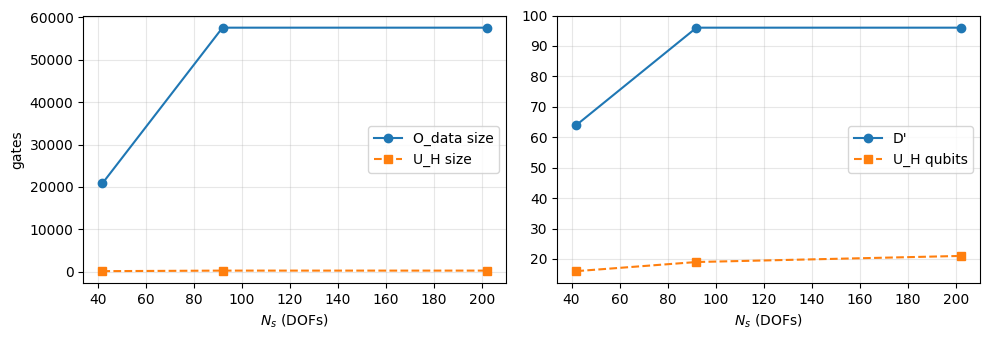

In [15]:
uh_scale = summarize_uh_gate_scaling(
    ((2, 2, 2), (4, 2, 2), (4, 4, 2)),
    add_fractures=True,
    sk_t_count=False,
)
display(uh_scale)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(uh_scale["N_s"], uh_scale["O_data_size"], "o-", label="O_data size")
ax[0].plot(uh_scale["N_s"], uh_scale["U_H_size"], "s--", label="U_H size")
ax[0].set_xlabel(r"$N_s$ (DOFs)")
ax[0].set_ylabel("gates")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(uh_scale["N_s"], uh_scale["D_prime"], "o-", label="D'")
ax[1].plot(uh_scale["N_s"], uh_scale["n_qubits_uh"], "s--", label="U_H qubits")
ax[1].set_xlabel(r"$N_s$ (DOFs)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Small-grid $U_H$ content vs classical $H$

A dense $2^{15}\times 2^{15}$ unitary is too large to materialize. Following the Laplacian notebook’s `verify_block_encoding` path, we verify **oracle content**:

1. classical reconstruction of $\mathrm{Im}(H)/\alpha$ from $(d,m)\to(i,j)$;
2. index-oracle chain $O_r\,O_c\,|d\,m\,0\rangle = |d\,m\,i\rangle$;
3. $O_{\mathrm{data}}$ amplitudes $|v_d|/\alpha$.

Clinic $H$ is purely imaginary Hermitian, so the encoded real payload is $\mathrm{Im}(H)$.

In [16]:
uh_cmp = compare_uh_to_classical(oracle)
display(pd.DataFrame([uh_cmp]))

assert uh_cmp["classical_recon_error"] < 1e-10
assert uh_cmp["index_oracle_ok"] == 1.0
assert uh_cmp["odata_amp_error"] < 1e-10

print(
    f"U_H content OK on 2x2x2: recon err = {uh_cmp['classical_recon_error']:.2e}, "
    f"O_data amp err = {uh_cmp['odata_amp_error']:.2e}, "
    f"registers = {int(uh_cmp['num_qubits_uh'])} qubits"
)

# Factor split also holds on the minimal grid
f_err = np.max(np.abs(dense_matrix(demo["H"]) - demo["factors"]["H_from_factors"]))
print(f"minimal-grid |H - i B^{{-1/2}} A B^{{-1/2}}|_max = {f_err:.2e}")
assert f_err < 1e-10


,alpha,classical_recon_error,index_oracle_ok,odata_amp_error,num_qubits_uh,n_d_qubits,n_m_qubits,n_index_qubits
0,252081.85805,0.0,1.0,2.864375e-14,15.0,6.0,2.0,6.0


U_H content OK on 2x2x2: recon err = 0.00e+00, O_data amp err = 2.86e-14, registers = 15 qubits
minimal-grid |H - i B^{-1/2} A B^{-1/2}|_max = 0.00e+00


## 11. Time evolution (replace `MatrixExponential`)

Clinic demonstrators used
`SparsePauliOp.from_operator(H.toarray())` + `PauliEvolutionGate(..., MatrixExponential())`, which densifies $H$ into hundreds of Pauli terms even on tiny grids.

**Replacement pipeline:**
1. Assemble $H$ from $U_H$ oracles (`value_table` + $(d,m)\to(i,j)$).
2. Evolve on the system register (pad $N\to 2^n$) with a single SciPy / `UnitaryGate` $\mathrm{e}^{-iHt}$ — no Pauli synthesis.
3. Compare to direct sparse $\mathrm{e}^{-iHt}\psi$ on the same $H$.

Full qubitization calling the 15-qubit block-encoding unitary remains future work; here the **access model** is oracle-assembled $H$, matching Aim 1’s “replace MatrixExponential” success criterion.

In [17]:
# Homogeneous 2x2x2: oracles already built as `oracle` / `demo` in Section 7–8
rng = np.random.default_rng(0)
psi0 = rng.normal(size=demo["layout"].n_total) + 1j * rng.normal(size=demo["layout"].n_total)
psi0 /= np.linalg.norm(psi0)
t_evol = 1e-6

evo_cmp = compare_evolution_to_direct(oracle, demo["H"], psi0, t_evol)
display(pd.DataFrame([evo_cmp]))

assert evo_cmp["oracle_vs_direct_H"] < 1e-10
assert evo_cmp["qiskit_vs_direct_psi"] < 1e-8

path = evolve_with_assembled_uh(oracle, psi0, t_evol, backend="structured_qiskit")
print("Structured evolution circuit:")
print(f"  system qubits: {path['n_qubits']}  (padded dim {2 ** path['n_qubits']})")
print(f"  ops: {dict(path['circuit'].count_ops())}")
print(
    f"Clinic Pauli baseline on same H: {path['pauli_baseline']['n_pauli_terms']} SparsePauliOp terms "
    f"vs nnz={path['pauli_baseline']['hamiltonian_nnz']}"
)
print(
    f"psi error (structured Qiskit vs direct sparse): {evo_cmp['qiskit_vs_direct_psi']:.2e}"
)


,time,oracle_vs_direct_H,sparse_oracle_vs_direct_psi,qiskit_vs_direct_psi,qiskit_vs_sparse_psi,n_qubits,n_pauli_terms_baseline,hamiltonian_nnz
0,0.000001,0.0,0.0,1.279461e-14,1.279461e-14,6.0,688.0,96.0


Structured evolution circuit:
  system qubits: 6  (padded dim 64)
  ops: {'state_preparation': 1, 'unitary': 1}
Clinic Pauli baseline on same H: 688 SparsePauliOp terms vs nnz=96
psi error (structured Qiskit vs direct sparse): 1.28e-14
